# 24RB1003 松澤颯斗

# 演習：スペクトルクラスタリング

# 課題１

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### 12頂点のグラフを2分割（$K=2$）する状況を考える．接続のない2つの部分グラフからなる隣接行列 $W$ を定義する

In [2]:
# 6x6の1が埋まった行列
block_ones = np.ones((6, 6))
# 12x12のゼロ行列
W = np.zeros((12, 12))
# 上半分にブロックを配置
W[:6, :6] = block_ones
# 下半分にブロックを配置
W[6:, 6:] = block_ones
W

array([[1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.]])

### 1. グラフラプラシアン $L$ を計算し，0固有値がちょうど $K$ 個になることを確認

In [3]:
# 次数行列 D を計算する
D = np.diag(np.sum(W, axis=1))
D

array([[6., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 6., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 6., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 6., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 6., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 6., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 6., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 6., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 6., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 6., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 6., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 6.]])

In [4]:
# グラフラプラシアンLを計算する
L = D - W
L

array([[ 5., -1., -1., -1., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-1.,  5., -1., -1., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-1., -1.,  5., -1., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-1., -1., -1.,  5., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-1., -1., -1., -1.,  5., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-1., -1., -1., -1., -1.,  5.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  5., -1., -1., -1., -1., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  5., -1., -1., -1., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1., -1.,  5., -1., -1., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1., -1., -1.,  5., -1., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1., -1., -1., -1.,  5., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1., -1., -1., -1., -1.,  5.]])

In [5]:
# 0固有値がちょうどK個になることを確認
eigenvalues = np.linalg.eigvals(L)

eigenvalues

array([ 6.00000000e+00, -6.66133815e-16,  6.00000000e+00,  6.00000000e+00,
        6.00000000e+00,  6.00000000e+00,  6.00000000e+00, -6.66133815e-16,
        6.00000000e+00,  6.00000000e+00,  6.00000000e+00,  6.00000000e+00])

In [6]:
# 0固有値の個数を数える
zero_eigenvalues = np.sum(np.isclose(eigenvalues, 0))
zero_eigenvalues

np.int64(2)

### 2. 行列 $W$ の値が0である部分に小さな正のノイズを加える．その際 $W$ の対称性が保たれる様に注意するべきだが，それを怠った場合で，$W$ の固有値を計算してみる．


In [7]:
# 0から0.1くらいの小さなノイズを用意
noise = np.random.rand(12, 12) * 0.1

# Wの値が0である部分にノイズを加える
W_noise = W + (noise * (W == 0))    

In [8]:
# W_noiseの固有値を計算
eigenvalues_noise = np.linalg.eigvals(W_noise)

eigenvalues_noise

array([ 6.31378809e+00+0.j        ,  5.68628886e+00+0.j        ,
        6.60553933e-02+0.j        , -6.63294527e-02+0.j        ,
        1.06261049e-05+0.04268162j,  1.06261049e-05-0.04268162j,
       -2.77843294e-02+0.0267512j , -2.77843294e-02-0.0267512j ,
       -2.76725610e-02+0.j        ,  2.79682483e-02+0.02678078j,
        2.79682483e-02-0.02678078j,  2.74805870e-02+0.j        ])

対称性が崩れたことで，複素数の固有値が現れた．

### 3. 対称性を保つように $W \leftarrow \frac{1}{2}W + \frac{1}{2}W^\top$ で隣接行列を再定義する．グラフラプラシアン $L$ の固有値を計算し，横軸が固有値のインデックス，縦軸が固有値の値でプロットする．


In [9]:
# 対称性を保つように隣接行列を再定義
W_sym = 0.5 * W_noise + 0.5 * W_noise.T
D_sym = np.diag(np.sum(W_sym, axis=1))
L_sym = D_sym - W_sym

In [10]:
#グラフラプラシアンLの固有値を計算
eigenvalues_sym = np.linalg.eigvals(L_sym)

eigenvalues_sym

array([1.11022302e-16, 6.26395589e-01, 6.22095727e+00, 6.22603517e+00,
       6.27147835e+00, 6.28155158e+00, 6.40018383e+00, 6.38706849e+00,
       6.31567389e+00, 6.32034432e+00, 6.36231967e+00, 6.35466813e+00])

0固有値が1つだけになった

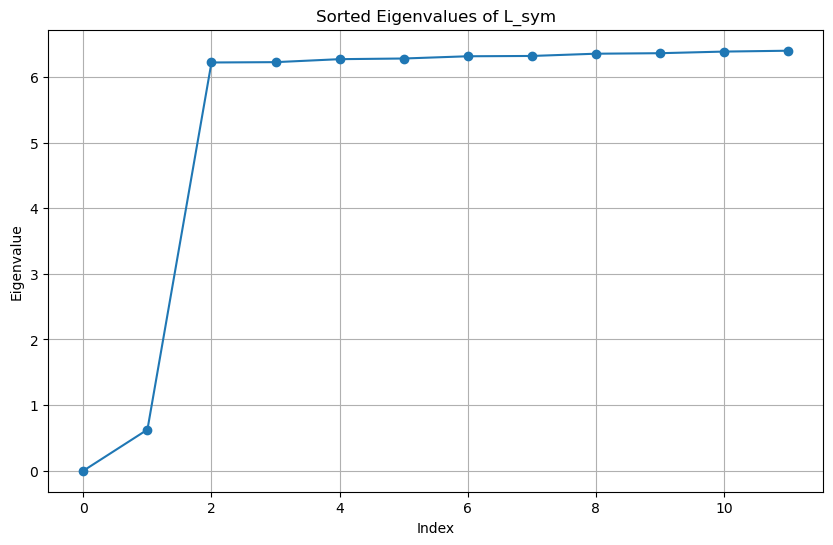

In [11]:
# 固有値を小さい順にソート
eigenvalues_sym_sorted = np.sort(eigenvalues_sym)
# グラフをプロット
plt.figure(figsize=(10, 6))
plt.plot(eigenvalues_sym_sorted, marker='o')
plt.title('Sorted Eigenvalues of L_sym')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

### 観察メモ
- インデックス0 ($\lambda_1\approx0$): グラフ全体が孤立せず，1つの連結成分として繋がっていることを示している．
- インデックス1 ($\lambda_2\approx0.55$): 追加したノイズにより，2つのグループ間に弱い結合が生まれたことを示している．
- インデックス2以降 ($\lambda_3\approx6.2\sim$): 各グループ内部の強い結合（各頂点の次数が約6であること）を反映している．

### グラフを描画

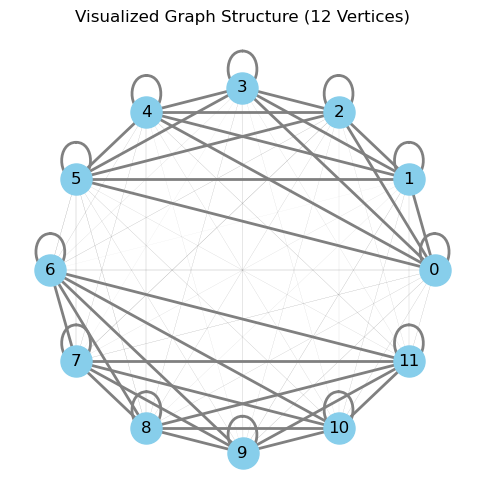

In [12]:
import networkx as nx

# グラフオブジェクトの作成
G = nx.from_numpy_array(W_sym)

# 頂点の配置
pos = nx.circular_layout(G)

# 辺の重み（類似度）に応じて線の太さを変えて描画
edges = G.edges(data=True)
weights = [d['weight'] * 2 for u, v, d in edges] # 見やすくするために太さを倍にする

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray')

plt.title("Visualized Graph Structure (12 Vertices)")
plt.axis('off')
plt.show()

# 課題２

### `sklearn.datasets.make_moons` （$n=200$， `noise=0.1` 程度）に対してスペクトラルクラスタリングを行い，うまく分割できることを確認

In [13]:
# RBFカーネルにより類似度行列 を定義し，スペクトラルクラスタリングを行え．クラスタリング結果は元の 2 次元空間にクラスタ割当を色分けしてプロットせよ．RBFカーネルのパラメータ を変えた場合を比較せよ．
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.1, random_state=0)

### K-meansの実行

In [14]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)

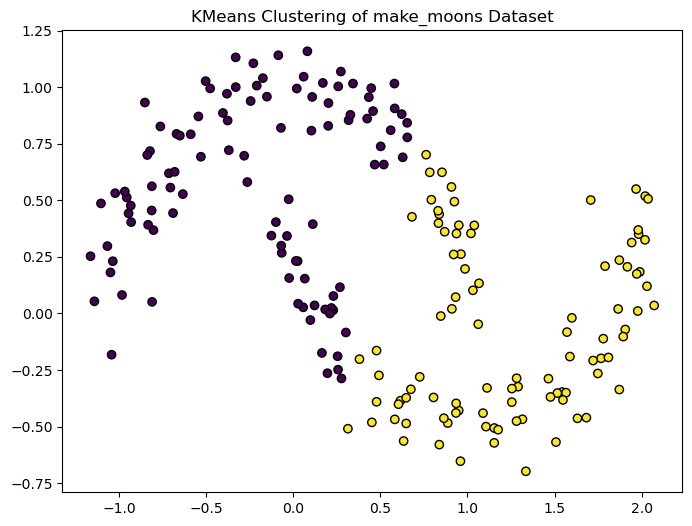

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k')
plt.title("KMeans Clustering of make_moons Dataset")
plt.show()

K-meansはクラスタが球状であると仮定しているため，三日月型のような非球状のデータではうまくいかない．

### 1. RBFカーネルを使って類似度行列 $W$ を構成

In [16]:
from sklearn.metrics.pairwise import rbf_kernel
W_rbf = rbf_kernel(X, gamma=30.0)  # gamma は RBF カーネルのパラメータ
np.fill_diagonal(W_rbf, 0)  # 対角成分を0にする（自己類似度を除く）

W_rbf

array([[0.00000000e+00, 4.48877857e-22, 4.53974119e-11, ...,
        1.86858802e-08, 2.93695552e-09, 3.03818470e-15],
       [4.48877857e-22, 0.00000000e+00, 2.69041443e-45, ...,
        7.18944033e-30, 3.08781719e-57, 1.00902695e-01],
       [4.53974119e-11, 2.69041443e-45, 0.00000000e+00, ...,
        1.15767230e-02, 8.32685168e-09, 3.63714496e-39],
       ...,
       [1.86858802e-08, 7.18944033e-30, 1.15767230e-02, ...,
        0.00000000e+00, 2.69632151e-14, 5.80696534e-26],
       [2.93695552e-09, 3.08781719e-57, 8.32685168e-09, ...,
        2.69632151e-14, 0.00000000e+00, 4.99535200e-46],
       [3.03818470e-15, 1.00902695e-01, 3.63714496e-39, ...,
        5.80696534e-26, 4.99535200e-46, 0.00000000e+00]], shape=(200, 200))

### 2. ラプラシアン $L=D-W$ の計算

In [17]:
D_rbf = np.diag(np.sum(W_rbf, axis=1))
L_rbf = D_rbf - W_rbf

### 3. $L$ の小さい固有値から $K=2$ 個の固有ベクトルを求める

In [18]:
eigenvalues, eigenvectors = np.linalg.eigh(L_rbf)

eigenvalues

array([1.43042600e-15, 1.59101471e-02, 5.95855100e-02, 6.59527537e-02,
       1.87994277e-01, 2.17739127e-01, 2.91111133e-01, 4.40883075e-01,
       4.74436139e-01, 6.12734952e-01, 6.81218371e-01, 8.45413887e-01,
       1.01085916e+00, 1.09678564e+00, 1.12605653e+00, 1.37756704e+00,
       1.43846235e+00, 1.48830365e+00, 1.50023287e+00, 1.62011048e+00,
       1.77648010e+00, 1.98372063e+00, 2.10617282e+00, 2.26916898e+00,
       2.39780441e+00, 2.45180185e+00, 2.60229993e+00, 2.67577411e+00,
       2.74389707e+00, 2.81206026e+00, 2.90014507e+00, 3.02842913e+00,
       3.05047731e+00, 3.11201179e+00, 3.22567808e+00, 3.30935672e+00,
       3.34527820e+00, 3.37143979e+00, 3.43389993e+00, 3.53235180e+00,
       3.58591069e+00, 3.62775447e+00, 3.66682395e+00, 3.86261184e+00,
       3.93101358e+00, 3.98633308e+00, 4.01687767e+00, 4.02858771e+00,
       4.12172490e+00, 4.17266757e+00, 4.24889219e+00, 4.26077633e+00,
       4.29743913e+00, 4.32503337e+00, 4.53152844e+00, 4.54989771e+00,
      

In [19]:
eigenvalues_sorted_indices = np.argsort(eigenvalues)

# 小さい固有値からK個のインデックスを取得
K = 2
selected_indices = eigenvalues_sorted_indices[:K]

### 4. 各点 $i$ を $\mathbb{R}^K$ に埋め込む

In [20]:
embedding = eigenvectors[:, selected_indices]

### 5. 埋め込んだ点を K-means でクラスタリング

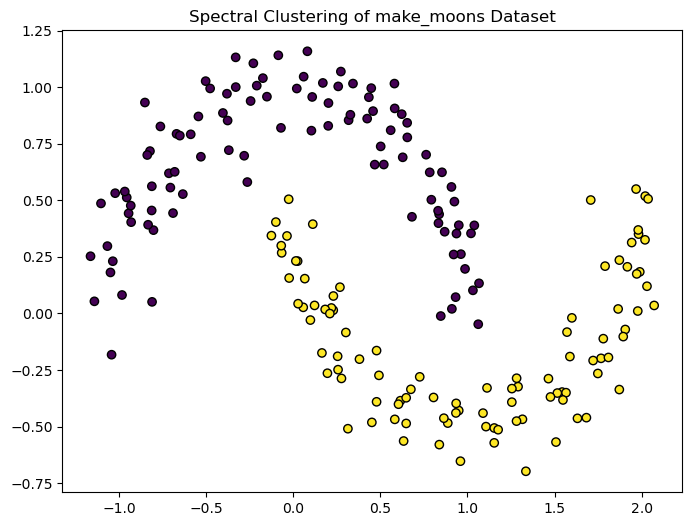

In [21]:
kmeans_embedding = KMeans(n_clusters=K, random_state=0)
labels_embedding = kmeans_embedding.fit_predict(embedding)      
# 埋め込んだ点を元の2次元空間にプロット
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_embedding, cmap='viridis', edgecolor='k')
plt.title("Spectral Clustering of make_moons Dataset")
plt.show()

### 観察メモ

1. K-meansの限界
- 結果: 絡み合う2つの三日月が，形状を無視して直線的な境界で不自然に分割されてしまった．
- 理由: K-meansはデータが球状に分布しているという仮定を持つため，三日月型のような複雑な非線形構造を正しく捉えることができないためである．

2. スペクトルクラスタリングの成功要因
- 結果: 2つの三日月を元の形状に沿って完璧に分離できた．
- 理由: RBFカーネルを用いてデータ間の関係をグラフの類似度として表現し，グラフラプラシアンの固有ベクトルを用いて新しい空間へ埋め込むことで，元の多様体構造を保持したままクラスタリングできたためである．

3. カーネルパラメータの重要性
- `gamma=1.0` の場合: 距離の許容範囲が広すぎたため，三日月の間の隙間を飛び越えて異なるグループの点同士が結びついてしまい，分離に失敗した．
- `gamma=15.0` の場合: 距離の許容範囲を狭く設定したことで，同じ三日月上の本当に近い点同士のみが強く結ばれ，正しくクラスタリングが実現した．

### 埋め込み空間をプロット

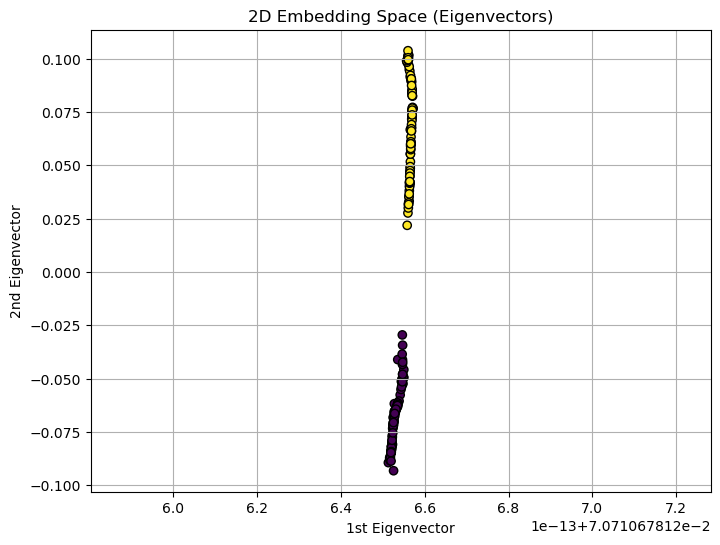

In [22]:
import matplotlib.pyplot as plt

# 埋め込み空間（固有ベクトル空間）のプロット
plt.figure(figsize=(8, 6))

# X軸に1番目の固有ベクトル、Y軸に2番目の固有ベクトルを指定
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels_embedding, cmap='viridis', edgecolor='k')

plt.title("2D Embedding Space (Eigenvectors)")
plt.xlabel("1st Eigenvector")
plt.ylabel("2nd Eigenvector")
plt.grid(True)
plt.show()

- 1番目の固有ベクトル（X軸）: すべての点がほぼ同じ値の場所に集まり，縦一直線に並んでいる．

- 2番目の固有ベクトル（Y軸）: 黄色のクラスタはプラスの領域に，紫のクラスタはマイナスの領域に配置され，上下に真っ二つに分かれている．

# 考察

課題１ではグラフラプラシアンの固有値と固有ベクトルを解析することで，データのグループ構造を抽出できることが示された．また，微小なノイズによる弱い結合が存在する場合でも，0に近い固有値の振る舞いを観察することで，グループ間の結びつきの度合いを定量的に捉えることができると考えられる．課題２の非球状データに対しては，RBFカーネルを用いてデータ間の距離をグラフの類似度に変換し，固有ベクトル空間へ写像を行うアプローチが有効であった．この写像により，元の空間では複雑に絡み合っていたデータが線形分離可能な状態へと変換され，K-meansでも正確に分類できるようになることが視覚的にも確認できた．

# AI使用について

Gemini Guided Learningを使用して，ネットワーク図の作成やスペクトルクラスタリングの一連の実装方法について質問した．AI に直接コードを生成させることはせず，実装の方針や考え方のヒントのみをもらい，それをもとに自身でコードを作成した．なお，プロットなどの実際のコーディング作業においては，GitHub Copilotの自動補完を補助的に活用してコードを生成した．